<a href="https://colab.research.google.com/github/al7arbi-111/options-pricer/blob/main/options_pricer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, kind="call"):
    d1 = (np.log(S/K) + (r + sigma**2/2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20

print(f"call {black_scholes(S, K, T, r, sigma):.4f}")
print(f"put  {black_scholes(S, K, T, r, sigma, 'put'):.4f}")

call 10.4506
put  5.5735


In [2]:
c = black_scholes(S, K, T, r, sigma)
p = black_scholes(S, K, T, r, sigma, "put")
print(f"C - P      = {c - p:.6f}")
print(f"S - Ke^-rT = {S - K*np.exp(-r*T):.6f}")

C - P      = 4.877058
S - Ke^-rT = 4.877058


In [3]:
def monte_carlo(S, K, T, r, sigma, n=100_000, kind="call", seed=0):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n)
    ST = S * np.exp((r - sigma**2/2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    disc = np.exp(-r*T) * payoff
    return disc.mean(), disc.std() / np.sqrt(n)

price, se = monte_carlo(S, K, T, r, sigma)
exact = black_scholes(S, K, T, r, sigma)

print(f"Monte Carlo   {price:.4f}  ± {1.96*se:.4f}")
print(f"Black-Scholes {exact:.4f}")
print(f"difference    {price - exact:+.4f}")

Monte Carlo   10.4362  ± 0.0912
Black-Scholes 10.4506
difference    -0.0144


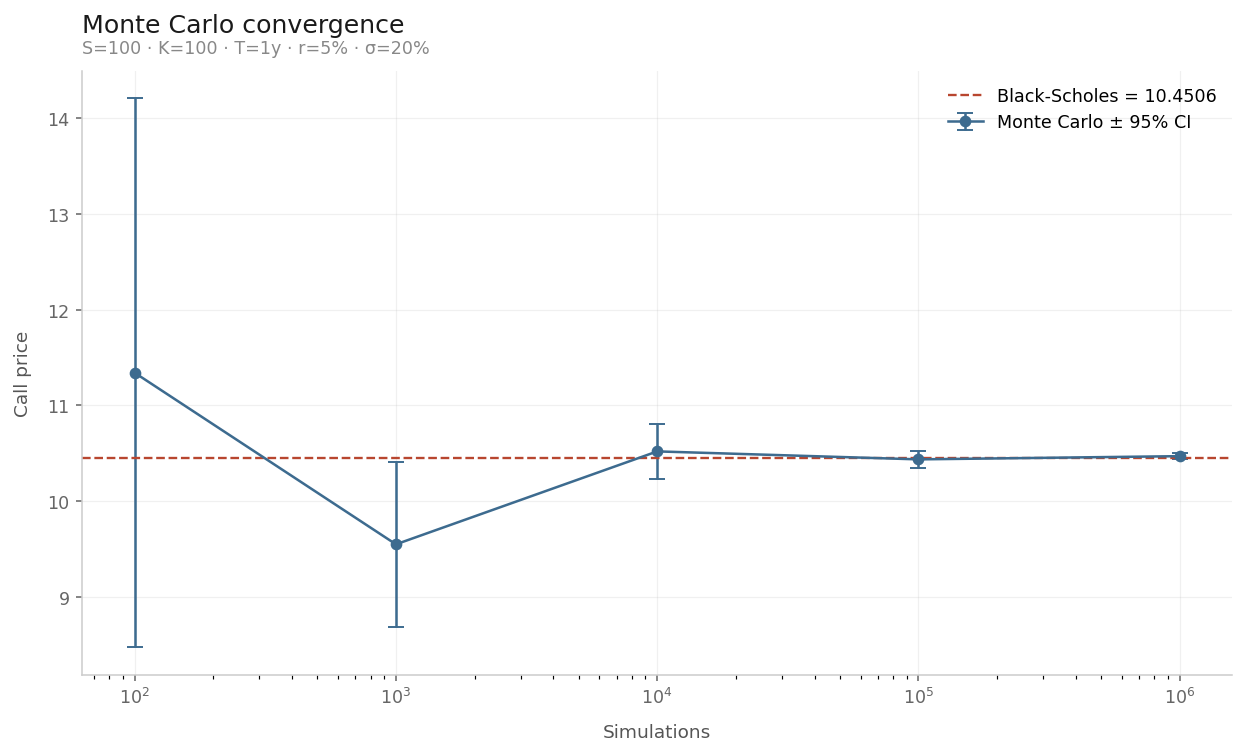

In [4]:
import matplotlib.pyplot as plt

sizes = [10**k for k in range(2, 7)]
res = [monte_carlo(S, K, T, r, sigma, n=n) for n in sizes]
prices = np.array([x[0] for x in res])
errs = np.array([1.96*x[1] for x in res])

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)
ax.errorbar(sizes, prices, yerr=errs, fmt="o-", color="#3d6b8f",
            linewidth=1.3, markersize=5, capsize=4, label="Monte Carlo ± 95% CI")
ax.axhline(exact, color="#b8462f", linewidth=1.2, linestyle="--",
           label=f"Black-Scholes = {exact:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Simulations", fontsize=9.5, color="#555", labelpad=8)
ax.set_ylabel("Call price", fontsize=9.5, color="#555", labelpad=8)
ax.set_title("Monte Carlo convergence", fontsize=13, loc="left", pad=20, color="#1a1a1a")
ax.text(0, 1.03, "S=100 · K=100 · T=1y · r=5% · σ=20%",
        transform=ax.transAxes, fontsize=9, color="#888")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.18, linewidth=0.6); ax.set_axisbelow(True)
ax.tick_params(labelsize=9, colors="#666", length=3)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color("#ccc"); ax.spines[s].set_linewidth(0.8)
plt.tight_layout(); plt.show()

In [5]:
def greeks(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return {
        "delta": norm.cdf(d1),
        "gamma": norm.pdf(d1) / (S * sigma * np.sqrt(T)),
        "vega":  S * norm.pdf(d1) * np.sqrt(T) / 100,
        "theta": (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365,
        "rho":   K * T * np.exp(-r*T) * norm.cdf(d2) / 100,
    }

for k, v in greeks(S, K, T, r, sigma).items():
    print(f"{k:<6} {v:+.4f}")

delta  +0.6368
gamma  +0.0188
vega   +0.3752
theta  -0.0176
rho    +0.5323


In [6]:
strikes = np.linspace(70, 130, 13)
print(f"{'K':>6} {'BS':>9} {'MC':>9} {'diff':>8}")
for k in strikes:
    bs = black_scholes(S, k, T, r, sigma)
    mc, _ = monte_carlo(S, k, T, r, sigma, n=200_000)
    print(f"{k:6.0f} {bs:9.4f} {mc:9.4f} {mc-bs:+8.4f}")

     K        BS        MC     diff
    70   33.5401   33.5497  +0.0096
    75   28.9744   28.9837  +0.0094
    80   24.5888   24.5980  +0.0091
    85   20.4693   20.4810  +0.0117
    90   16.6994   16.7137  +0.0142
    95   13.3465   13.3614  +0.0150
   100   10.4506   10.4645  +0.0139
   105    8.0214    8.0342  +0.0129
   110    6.0401    6.0486  +0.0085
   115    4.4666    4.4707  +0.0041
   120    3.2475    3.2489  +0.0014
   125    2.3243    2.3264  +0.0022
   130    1.6396    1.6427  +0.0031


In [7]:
print("seed variation at K=100:")
for s in range(5):
    mc, se = monte_carlo(S, 100, T, r, sigma, n=200_000, seed=s)
    print(f"  seed {s}: {mc:.4f}  diff {mc-black_scholes(S,100,T,r,sigma):+.4f}")

print("\nextreme strikes, relative error:")
for k in [150, 175, 200]:
    bs = black_scholes(S, k, T, r, sigma)
    mc, se = monte_carlo(S, k, T, r, sigma, n=200_000, seed=1)
    print(f"  K={k}: BS {bs:.5f}  MC {mc:.5f}  rel err {(mc-bs)/bs*100:+6.2f}%")

seed variation at K=100:
  seed 0: 10.4645  diff +0.0139
  seed 1: 10.3993  diff -0.0513
  seed 2: 10.4298  diff -0.0208
  seed 3: 10.4496  diff -0.0010
  seed 4: 10.5047  diff +0.0541

extreme strikes, relative error:
  K=150: BS 0.35963  MC 0.35955  rel err  -0.02%
  K=175: BS 0.04433  MC 0.04645  rel err  +4.79%
  K=200: BS 0.00480  MC 0.00528  rel err  +9.92%


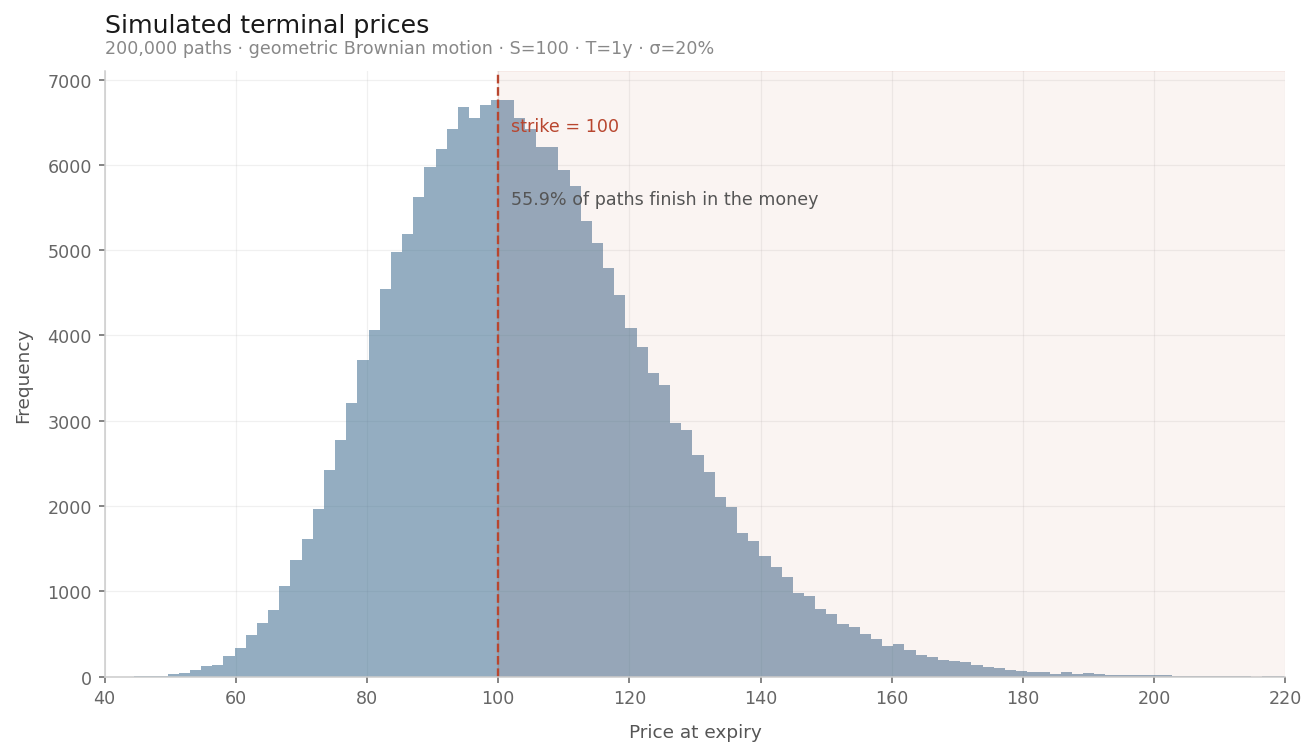

In [8]:
rng = np.random.default_rng(1)
ST = S * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*rng.standard_normal(200_000))

fig, ax = plt.subplots(figsize=(9.5, 5.5), dpi=140)
ax.hist(ST, bins=120, color="#3d6b8f", alpha=0.55, linewidth=0)
ax.axvline(K, color="#b8462f", linewidth=1.2, linestyle="--")
ax.text(K+2, ax.get_ylim()[1]*0.9, f"strike = {K}", fontsize=9, color="#b8462f")
ax.axvspan(K, ST.max(), color="#b8462f", alpha=0.06)
ax.text(K+2, ax.get_ylim()[1]*0.78,
        f"{(ST>K).mean()*100:.1f}% of paths finish in the money",
        fontsize=9, color="#555")
ax.set_xlim(40, 220)
ax.set_title("Simulated terminal prices", fontsize=13, loc="left", pad=20, color="#1a1a1a")
ax.text(0, 1.03, "200,000 paths · geometric Brownian motion · S=100 · T=1y · σ=20%",
        transform=ax.transAxes, fontsize=9, color="#888")
ax.set_xlabel("Price at expiry", fontsize=9.5, color="#555", labelpad=8)
ax.set_ylabel("Frequency", fontsize=9.5, color="#555", labelpad=8)
ax.grid(alpha=0.18, linewidth=0.6); ax.set_axisbelow(True)
ax.tick_params(labelsize=9, colors="#666", length=3)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color("#ccc"); ax.spines[s].set_linewidth(0.8)
plt.tight_layout(); plt.show()